Дорогой студент!

В данном домашнем задании предоставляется возможность поработать с задачей по распознаванию позитивных и негативных отзывы людей по автомобилю Tesla. База для обучения содержит два текстовых файла с рядом строчных отзывов с мнением людей об автомобиле Tesla, соответственно негативного и позитивного содержания. Ссылка на скачивание базы уже включена в ноутбук задания.


Необходимо выполнить следующие действия:

  1. Загрузите саму базу по ссылке и подговьте файлы базы для обработки.
  2. Создайте обучающую и проверочную выборки, обратив особое внимание на балансировку базы: количество примеров каждого класса должно быть примерно одного порядка.
  3. Подготовьте выборки для обучения и обучите сеть. Добейтесь результата точности сети в 85-90% на проверочной выборке.
   


**Импорт библиотек, загрузка базы и подготовка её к предобработке.**

In [122]:
# Работа с массивами данных
import numpy as np

# Работа с таблицами
import pandas as pd

import os 

import re

import pymorphy3

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Отрисовка графиков
import matplotlib.pyplot as plt


# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

from tensorflow.keras import regularizers

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D,  Embedding,  GlobalAveragePooling1D, BatchNormalization, TextVectorization

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

from sklearn.feature_extraction.text import CountVectorizer

# Заполнение последовательностей до определенной длины
from tensorflow.keras.preprocessing.sequence import pad_sequences


from sklearn.model_selection import train_test_split


# Для работы с файлами в Colaboratory
import os

import gdown

# Отрисовка графиков
import matplotlib.pyplot as plt

import tensorflow as tf

%matplotlib inline

In [126]:

# Задание параметров преобразования
VOCAB_SIZE = 5000                        # Объем словаря для токенизатора
MAX_LEN = 50

BATCH_SIZE = 16                 # Размер батча для обучения

DATA_DIR = "tesla"
CLASS_LIST = ["Негативный отзыв", "Позитивный отзыв"]
CLASS_COUNT = len(CLASS_LIST)


In [3]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/tesla.zip', None, quiet=True)

'tesla.zip'

**Деление общей базы отзывов на данные для обучения и проверки.**

In [4]:
# Распаковка архива в папку writers
!unzip -qo tesla.zip -d tesla/

# Просмотр содержимого папки
!ls tesla

'Негативный отзыв.txt'	'Позитивный отзыв.txt'


**Загрузка текста из файлов, преобразование в одну строку.**

## Чтение текстов и классов из файлов

In [111]:


data = []


with open(os.path.join(DATA_DIR, "Негативный отзыв.txt"), 'r', encoding='utf-8') as f:
    neg_texts = f.readlines()

for t in neg_texts:
    data.append({
        'text': t.strip(),
        'label': 0  
    })


    with open(os.path.join(DATA_DIR, "Позитивный отзыв.txt"), 'r', encoding='utf-8') as f:
        pos_texts = f.readlines()

for t in pos_texts:
    data.append({
        'text': t.strip(),
        'label': 1   
    })

df = pd.DataFrame(data)

print(df.shape)
display(df)

(3379, 2)


,text,label
0,После 170 на трассе она чувствует себя неувере...,0
1,Кстати сидения очень удобными тоже не назовёшь...,0
2,"Шляпа, а не авто, все не продумано до мелочей....",0
3,Прям фу фу фу и дизайн снаружи и внутри. Прода...,0
4,", негодование обычно возникает из-за несостояв...",0
...,...,...
3374,Тесла летает как ракета,1
3375,космос,1
3376,КРУТОТЕНЬ👍👍👍😎😎😎,1
3377,космомобиль,1


## Очистка текста от муосра

In [112]:
morph = pymorphy3.MorphAnalyzer()

def clean_text(text):
    text = re.sub(r'[^а-яА-Яa-zA-Z]', ' ', text.lower())
    # Лемматизация каждого слова
    words = [morph.parse(word)[0].normal_form for word in text.split()]
    return ' '.join(words)

In [113]:
df['text'] = df['text'].apply(clean_text)
display(df)

,text,label
0,после на трасса она чувствовать себя неуверенно,0
1,кстати сидение очень удобный тоже не назов шь ...,0
2,шляпа а не авто всё не продумать до мелочь пок...,0
3,прям фу фу фу и дизайн снаружи и внутри продат...,0
4,негодование обычно возникать из за несостоявши...,0
...,...,...
3374,тесло летать как ракета,1
3375,космос,1
3376,крутотень,1
3377,космомобиль,1


## Балансировка классов

In [114]:
min_len = df['label'].value_counts().min()

df_balanced = df.groupby('label').sample(min_len, random_state=42)
display(df_balanced['label'].value_counts())
display(df['label'].value_counts())

,count
label,
0,1188
1,1188


,count
label,
1,2191
0,1188


## Разделение на обучающую и тестовую выборки

In [115]:


X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['text'],
    df_balanced['label'],

    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']

)
print(X_train)

866     зачем акума изготовить из мелкий это же не рен...
453     слишком много ограничение в тесло слишком мног...
1045    эска морочить голова с батарея потому что она ...
639                           поставить солнечный батарея
2746    тесло очень крутой машина если она можно так н...
                              ...                        
57                 главное доступность авто а не до сотня
633     центральный консоль быстро мараться неудобный ...
3131                   круть новинка правда очень быстрый
283     покупать машина стоймость как дом и каждый раз...
761     за такой деньга хотеться роскошь как внутри та...
Name: text, Length: 1900, dtype: object


## Векторизация текстовых данных с использованием TF-IDF и n-грамм

In [127]:

vectorize_layer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode='tf_idf', 
    ngrams=(1, 2)        
)


vectorize_layer.adapt(X_train)

X_train_vec = vectorize_layer(X_train)
X_test_vec = vectorize_layer(X_test)

## Построение и обучнеие сети

In [117]:
def compile_model(model,
                    x_train,
                    y_train,
                    x_val,
                    y_val,
                    optimizer='adam',
                    epochs=50,
                    batch_size=BATCH_SIZE,):

    callback = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=5,
        restore_best_weights=True)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy'])

    model.summary()

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        callbacks=[callback],
        verbose=1)
    return history

In [118]:
def plot_history(history, figsize=(12, 4)):
    plt.figure(figsize=figsize)

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Точность на обучении')
    plt.plot(history.history['val_accuracy'], label='Точность на валидации')
    plt.title('Точность модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Потери на обучении')
    plt.plot(history.history['val_loss'], label='Потери на валидации')
    plt.title('Потери модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [119]:
def eval_model(model, x, y_true, class_labels, title='', figsize=(10, 10)):

    y_pred = model.predict(x)

    y_pred_cls = (y_pred > 0.5).astype(int).reshape(-1)
    y_true_cls = y_true

    acc = (y_pred_cls == y_true_cls).mean()

    cm = confusion_matrix(
        y_true_cls,
        y_pred_cls,
        labels=range(len(class_labels)),
        normalize='true'
    )

    cm_rounded = np.around(cm, 3)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Confusion Matrix: {title}', fontsize=16)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_rounded,
        display_labels=class_labels
    )

    disp.plot(ax=ax, cmap='Blues')

    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    print('-' * 80)
    print(f'Accuracy: {acc:.4f}')

    class_accuracy = np.diag(cm)

    for i, label in enumerate(class_labels):
        print(f"{label:<20} → {class_accuracy[i]:.4f}")

    print(f"\nMean class accuracy: {np.mean(class_accuracy):.4f}")

In [120]:
def compile_train_eval_model(
    model,
    x_train,
    y_train,
    x_test,
    y_test,
    class_labels,
    title='',
    optimizer='adam',
    epochs=50,
    batch_size=BATCH_SIZE,
):

    history = compile_model(   
        model,
        x_train, y_train,
        x_test, y_test,
        optimizer=optimizer,
        epochs=epochs,
        batch_size=batch_size,
    )

    plot_history(history) 

    eval_model(
        model,
        x_test,
        y_test,
        class_labels=class_labels,
        title=title,
    )

    return history   

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 128)            │       640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649,217 (2.48 MB)

 Trainable params: 648,833 (2.48 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5563 - loss: 0.7976 - val_accuracy: 0.6429 - val_loss: 0.6354
Epoch 2/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6626 - loss: 0.6146 - val_accuracy: 0.6891 - val_loss: 0.5984
Epoch 3/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7695 - loss: 0.4714 - val_accuracy: 0.7227 - val_loss: 0.5586
Epoch 4/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8232 - loss: 0.3859 - val_accuracy: 0.7311 - val_loss: 0.5138
Epoch 5/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8589 - loss: 0.3326 - val_accuracy: 0.7227 - val_loss: 0.6208
Epoch 6/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8832 - loss: 0.2743 - val_accuracy: 0.7710 - val_loss: 0.4942
Epoch 7/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8953 - loss: 0.2417 - val_accuracy: 0.7374 - val_loss: 0.5487
Epoch 8/50
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9116 - loss: 0.2262 - val_accuracy: 0

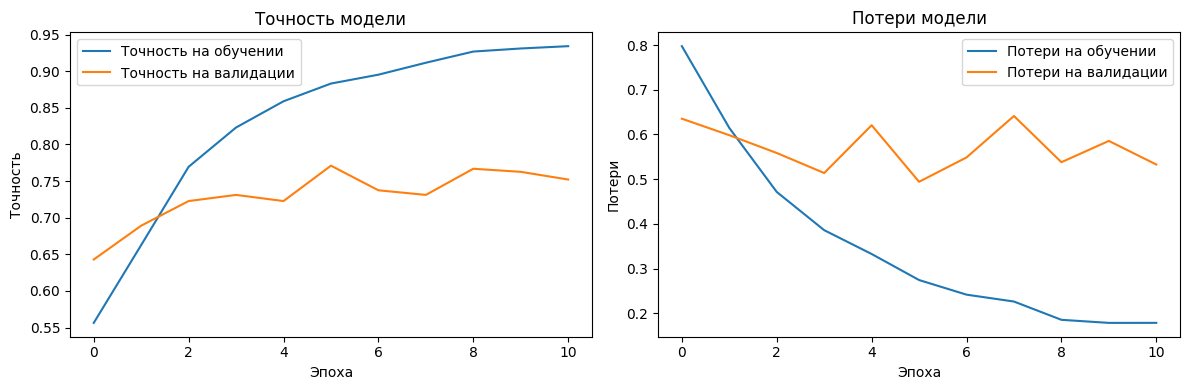

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


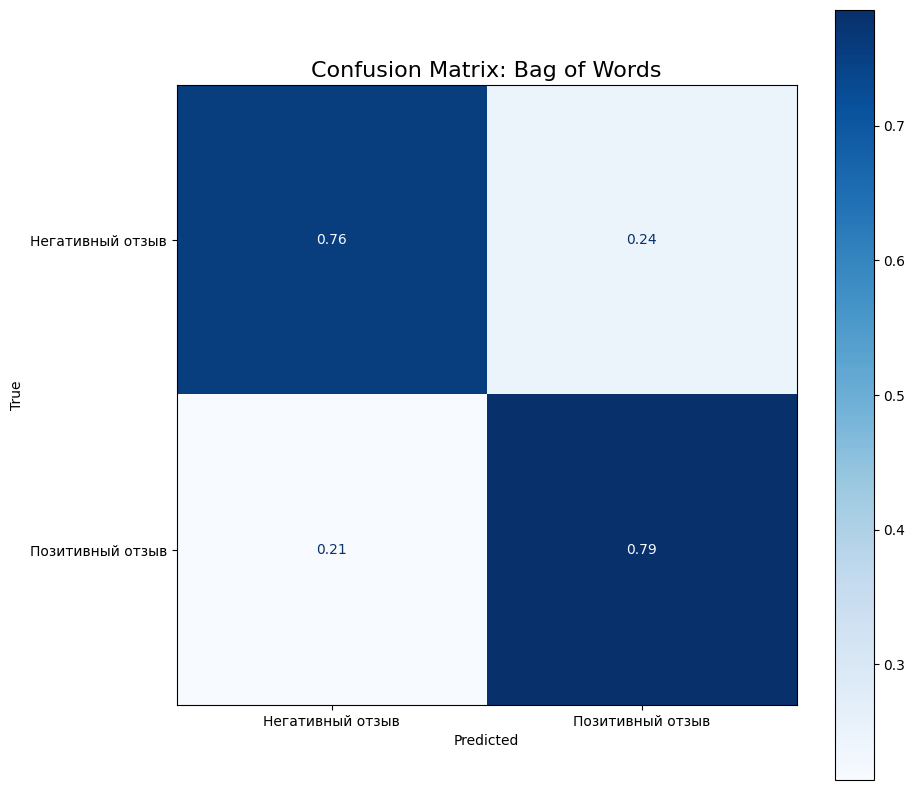

--------------------------------------------------------------------------------
Accuracy: 0.7710
Негативный отзыв     → 0.7563
Позитивный отзыв     → 0.7857

Mean class accuracy: 0.7710


In [134]:
model_bow = Sequential([
    Dense(128, activation='relu', input_shape=(VOCAB_SIZE,)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

compile_train_eval_model(model_bow,
                         X_train_vec, y_train,
                         X_test_vec, y_test,
                         class_labels=CLASS_LIST,
                         title='Bag of Words')